2025-11-14 11:08:16.807800: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763114896.848106    1079 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763114896.857536    1079 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763114896.942335    1079 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763114896.942367    1079 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763114896.942369    1079 computation_placer.cc:177] computation placer alr

Y_pks shape: (1000, 128)
lhs_scaled shape: (1000, 5)


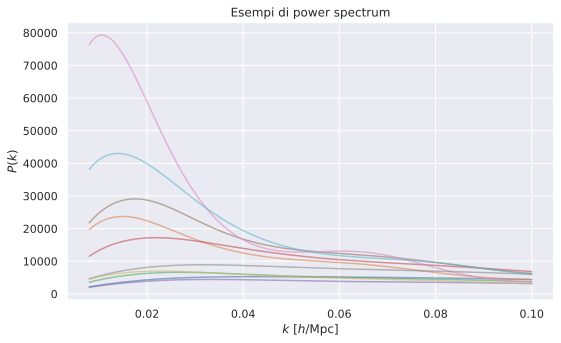

Shapes: (800, 128) (200, 128)


In [1]:
#!/usr/bin/env python
# coding: utf-8

## Standard libraries
import os
import json
import math
import numpy as np
import copy
from typing import Any, Sequence, Callable, NamedTuple, Optional, Tuple
PyTree = Any  
from copy import deepcopy
import pickle
import corner
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg', 'pdf')
import seaborn as sns
sns.set()
from tqdm.auto import tqdm
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import random
from jax import lax
from jax.tree_util import tree_map
main_rng = random.PRNGKey(42)
import jax_cosmo as jc
from jax_cosmo import power
from scipy.stats import qmc
import flax
from flax import linen as nn
from flax.training import train_state, checkpoints

import optax
import jax_cosmo as jc
from jax_cosmo import power
from scipy.stats import qmc
import sklearn
import functools

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import trange
RNG = random.PRNGKey(42)

N = 1000       
Nk = 128
k_min, k_max = 0.008, 0.1
k_vals = jnp.linspace(k_min, k_max, Nk)
z = 0.0
a = 1.0 / (1.0 + z)
variation = 0.1

param_0 = {
    r"$\Omega_c$": 0.264,
    r"$\Omega_b$": 0.049,
    r"h":       0.6736,
    r"$n_s$":     0.9649,
    r"$\sigma_8$":  0.8111,
}
param_names = [r'$\Omega_c$', r'$\Omega_b$', r'h', r'$n_s$', r'$\sigma_8$']
param_ranges = {
    p: [min(param_0[p] * (1 - variation), param_0[p] * (1 + variation)),
        max(param_0[p] * (1 - variation), param_0[p] * (1 + variation))]
    for p in param_names
}
param_bounds = jnp.array([
    [0.1, 0.5],     # Omega_m
    [0.03, 0.07],   # Omega_b
    [0.5, 0.9],     # h
    [0.8, 1.2],     # n_s
    [0.6, 1.0]      # sigma8
])
#param_bounds = jnp.array([param_ranges[p] for p in param_names])

n_dims = param_bounds.shape[0]

def create_lhs_fixed_dim(n_dims, n_samples):
    @jax.jit
    def inner(key):
        keys = jnp.array(jax.random.split(key, n_dims + 1))
        def gen_dim(i, val):
            key_i = keys[i]
            key_perm, key_rand = random.split(key_i)
            perm = random.permutation(key_perm, n_samples)
            rand = random.uniform(key_rand, (n_samples,))
            stratified = (perm + rand) / n_samples
            val = val.at[:, i].set(stratified)
            return val
        lhs = jnp.zeros((n_samples, n_dims))
        lhs = lax.fori_loop(0, n_dims, gen_dim, lhs)
        return lhs
    return inner

def scale_lhs(lhs, bounds):
    lows = bounds[:, 0]
    highs = bounds[:, 1]
    return lhs * (highs - lows) + lows

lhs_fn = create_lhs_fixed_dim(n_dims, N)
key, sub = random.split(RNG)
lhs_raw = lhs_fn(sub)
lhs_scaled = scale_lhs(lhs_raw, param_bounds)  

@jax.jit
def compute_pk(sample):
    Omega_c, Omega_b, h, n_s, sigma8 = sample
    cosmo = jc.Cosmology(
        Omega_c=Omega_c,
        Omega_b=Omega_b,
        h=h,
        n_s=n_s,
        sigma8=sigma8,
        Omega_k=0.0,
        w0=-1.0,
        wa=0.0
    )
    return power.linear_matter_power(cosmo, k_vals, a)

batched_pk = jax.jit(jax.vmap(compute_pk, in_axes=(0,)))
Y_pks = batched_pk(lhs_scaled)
print('Y_pks shape:', Y_pks.shape)
print('lhs_scaled shape:', lhs_scaled.shape)
plt.figure(figsize=(8, 5))
for i in range(10):
    plt.plot(k_vals, Y_pks[i], alpha=0.6)
plt.xlabel(r"$k \ [h/\mathrm{Mpc}]$")
plt.ylabel(r"$P(k)$")
plt.title("Esempi di power spectrum")
plt.grid(True)
plt.tight_layout()
plt.show()

# Standardizzazione
X_scaler = StandardScaler()
Y_scaler = StandardScaler()
X = X_scaler.fit_transform(np.asarray(Y_pks))
Y = Y_scaler.fit_transform(np.asarray(lhs_scaled))

X_ad, X_t, Y_ad, Y_t = train_test_split(X, Y, test_size=0.2, random_state=42)

print('Shapes:', X_ad.shape, X_t.shape)





In [5]:

# ============================================
# FISHER MATRIX
# ============================================

theta0 = jnp.array([param_0[p] for p in param_names])

@jax.jit
def jacobian_j(theta):
    J_fun = jax.jit(jax.jacfwd(compute_pk))
    return J_fun(theta)  
jacobian_jax=jax.jit(jacobian_j)

def jacobian(theta, d=1e-3):
    n_params = theta.shape[0]
    Pk = compute_pk(theta)
    Nk = Pk.shape[0]
    
    J = jnp.zeros((Nk, n_params))
    for j in range(n_params):
        theta_plus  = theta.at[j].set(theta[j]*(1+d))
        theta_minus = theta.at[j].set(theta[j]*(1-d))
        pk_plus  = compute_pk(theta_plus)
        pk_minus = compute_pk(theta_minus)
        dt = 2 * theta[j] * d
        J = J.at[:, j].set((pk_plus - pk_minus) / dt)
    return J

def centered_dk(k):
    dk = jnp.zeros_like(k)
    dk = dk.at[0].set(k[1] - k[0])
    dk = dk.at[1:-1].set(0.5 * (k[2:] - k[:-2]))
    dk = dk.at[-1].set(k[-1] - k[-2])
    return dk

def gaussian_pk_covariance_diag(Pk, k_vals, V):
    dk = centered_dk(k_vals)
    Nm = V * (k_vals**2) * dk / (2.0 * jnp.pi**2)
    var = 2.0 / Nm * (Pk) ** 2
    return var  

def fisher_matrix(theta, V): 
    Pk = compute_pk(theta)          
    J = jacobian(theta, d=1e-3)  
    Cdiag = jnp.diag(gaussian_pk_covariance_diag(Pk, k_vals, V))
    Cinv = jnp.linalg.inv(Cdiag)
    F = J.T @ Cinv @ J
    return F

def fisher_jax(theta, V): 
    Pk = compute_pk(theta)         
    J = jacobian_jax(theta) 
    Cdiag = jnp.diag(gaussian_pk_covariance_diag(Pk, k_vals, V))
    Cinv = jnp.linalg.inv(Cdiag)
    F = J.T @ Cinv @ J
    return F

V = (2*jnp.pi/k_min)**3
F = fisher_matrix(theta0, V)
F_j = fisher_jax(theta0, V)

sig_m = jnp.linalg.inv(F)
sig = jnp.sqrt(jnp.diag(sig_m))
rel = sig / theta0
sig_mj = jnp.linalg.inv(F_j)
sig_j = jnp.sqrt(jnp.diag(sig_mj))


In [6]:

# ============================================
# MODELLO + TRAINING
# ============================================

from copy import deepcopy
from tqdm import trange
from scipy.stats import linregress

def is_saturating(losses: list[float], window: int = 50, var_threshold: float = 1e-4) -> bool:
    if len(losses) < window:
        return False
    return np.var(losses[-window:]) < var_threshold

def loss_trend_stable(losses: list[float], window: int = 50, slope_threshold: float = 1e-4) -> bool:
    if len(losses) < window:
        return False
    y = np.array(losses[-window:])
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return abs(slope) < slope_threshold

class MLP(nn.Module):
    features: list[int]
    @nn.compact
    def __call__(self, x):
        for feat in self.features[:-1]:
            x = nn.Dense(feat)(x)
            x = nn.leaky_relu(x, negative_slope=0.5)
        x = nn.Dense(self.features[-1])(x)
        return x

def create_train_step(model, optimizer):
    @jax.jit
    def train_step(params, opt_state, x, y):
        def loss(params, x, y):
            preds = model.apply(params, x)
            mse_per_output = jnp.mean((preds - y) ** 2, axis=0)
            log_mse = jnp.log(mse_per_output + 1e-8)
            return jnp.sum(log_mse)
        loss_val, grads = jax.value_and_grad(loss)(params, x, y)
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss_val
    return train_step

def log_loss(params, x, y):
    preds = model.apply(params, x)
    mse_per_output = jnp.mean((preds - y) ** 2, axis=0)
    log_mse = jnp.log(mse_per_output + 1e-8)
    return jnp.sum(log_mse)

def mse_loss(params, x, y):
    preds = model.apply(params, x)
    return jnp.mean((preds - y) ** 2)

In [4]:

# ============================================
# LOOP DI TRAINING + SALVATAGGIO MODELLI
# ============================================

import time
from flax import serialization

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def save_params_file(params, path):
    ensure_dir(os.path.dirname(path))
    params_host = jax.device_get(params)
    b = serialization.to_bytes(params_host)
    with open(path, "wb") as f:
        f.write(b)

def save_pickle(obj, path):
    ensure_dir(os.path.dirname(path))
    with open(path, "wb") as f:
        pickle.dump(obj, f)

depths = [6,7,8,9,10]
width = 512
epochs = 1000
patience = 50
results = []
key = jax.random.PRNGKey(42)
save_dir = "saved_models_large"
ensure_dir(save_dir)

for d in depths:
    print(f"Testando profondità {d} hidden layer...")
    layer_sizes = [width] * d + [Y_ad.shape[1]]
    model = MLP(features=layer_sizes)
    key, subkey = jax.random.split(key)
    params = model.init(subkey, jnp.ones((1, X_ad.shape[1])))
    batch_size = 16
    steps_per_epoch = X_ad.shape[0] // batch_size

    scheduler = optax.exponential_decay(
        init_value=1e-3,
        transition_steps=steps_per_epoch * 10,
        decay_rate=0.9,
        staircase=True
    )

    optimizer = optax.adam(learning_rate=scheduler)
    opt_state = optimizer.init(params)
    train_step = create_train_step(model, optimizer)

    train_losses, val_losses, test_losses = [], [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_params = None
    best_epoch = 0

    for epoch in trange(epochs, desc=f"Training depth {d}"):
        key, subkey = jax.random.split(key)
        perm = jax.random.permutation(subkey, X_ad.shape[0])
        for i in range(steps_per_epoch):
            actual_batch = min(batch_size, X_ad.shape[0] - i * batch_size)
            idx = perm[i * batch_size : i * batch_size + actual_batch]
            x_batch = X_ad[idx]
            y_batch = Y_ad[idx]
            params, opt_state, loss = train_step(params, opt_state, x_batch, y_batch)

        train_loss = log_loss(params, X_ad, Y_ad)
        val_loss = log_loss(params, X_t, Y_t)
        test_loss = log_loss(params, X_t, Y_t)
        train_losses.append(float(train_loss))
        val_losses.append(float(val_loss))
        test_losses.append(float(test_loss))

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = deepcopy(params)
            best_epoch = epoch + 1
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience or is_saturating(val_losses) or loss_trend_stable(val_losses):
            print(f"Early stopping a epoca {epoch+1}")
            break

    print(f"Miglior modello con {d} layer ottenuto all'epoca {best_epoch} con validation loss = {best_val_loss:.6f}")

    ### SALVATAGGIO MODELLI ###
    ts = time.strftime("%Y%m%d-%H%M%S")
    model_fname = os.path.join(save_dir, f"mlp_large_depth{d}_width{width}_{ts}.params")
    meta_fname = os.path.join(save_dir, f"mlp_large_depth{d}_width{width}_{ts}.meta.pkl")

    print(f"→ Salvo pesi in {model_fname}")
    save_params_file(best_params, model_fname)
    meta = {
        "depth": d,
        "width": width,
        "best_epoch": best_epoch,
        "best_val_loss": float(best_val_loss),
        "final_test_loss": float(test_losses[-1]),
        "timestamp": ts,
        "model_fname": model_fname,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "test_losses": test_losses
    }
    save_pickle(meta, meta_fname)
    ### FINE SALVATAGGIO ###

    results.append({
        'depth': d,
        'best_val_loss': float(best_val_loss),
        'final_test_loss': float(test_losses[-1]),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'test_losses': test_losses,
        'best_params': None,
        'model_fname': model_fname,
        'meta_fname': meta_fname
    })

# salva anche scalers e risultati globali
save_pickle(X_scaler, os.path.join(save_dir, "X_scaler_large.pkl"))
save_pickle(Y_scaler, os.path.join(save_dir, "Y_scaler_large.pkl"))
save_pickle(results, os.path.join(save_dir, f"results_large_summary_{time.strftime('%Y%m%d-%H%M%S')}.pkl"))


Testando profondità 6 hidden layer...


Training depth 6:  90%|██████████████████████████████████████████████████████▏     | 903/1000 [3:15:09<20:57, 12.97s/it]

Early stopping a epoca 904
Miglior modello con 6 layer ottenuto all'epoca 894 con validation loss = -40.893383
→ Salvo pesi in saved_models_large/mlp_large_depth6_width512_20251027-000418.params
Testando profondità 7 hidden layer...



Training depth 7:  91%|██████████████████████████████████████████████████████▍     | 907/1000 [3:33:41<21:54, 14.14s/it]

Early stopping a epoca 908
Miglior modello con 7 layer ottenuto all'epoca 898 con validation loss = -41.790462
→ Salvo pesi in saved_models_large/mlp_large_depth7_width512_20251027-033800.params
Testando profondità 8 hidden layer...


...

Early stopping a epoca 651
Miglior modello con 8 layer ottenuto all'epoca 638 con validation loss = -41.437224
→ Salvo pesi in saved_models_large/mlp_large_depth8_width512_20251027-063800.params
Testando profondità 9 hidden layer...



Training depth 9:  59%|██████████████████████████████████▎                       | 591/1000 [3:36:55<2:30:07, 22.02s/it]

Early stopping a epoca 592
Miglior modello con 9 layer ottenuto all'epoca 589 con validation loss = -41.485579
→ Salvo pesi in saved_models_large/mlp_large_depth9_width512_20251027-101456.params
Testando profondità 10 hidden layer...



Training depth 10:  79%|█████████████████████████████████████████████▏           | 793/1000 [4:32:51<1:11:13, 20.65s/it]

Early stopping a epoca 794
Miglior modello con 10 layer ottenuto all'epoca 781 con validation loss = -41.672006
→ Salvo pesi in saved_models_large/mlp_large_depth10_width512_20251027-144748.params


In [8]:
import pickle
import flax.serialization as serialization
import jax.numpy as jnp

def load_params_file(model_fname, depth, width, input_dim, output_dim):
    """
    Carica i parametri salvati di un MLP da file.
    Tenta prima il formato pickle, poi Flax serialized.
    """
    if not os.path.exists(model_fname):
        print(f"File dei parametri non trovato: {model_fname}")
        return None

    try:
        # --- Caso 1: file salvato con pickle ---
        with open(model_fname, "rb") as f:
            params = pickle.load(f)
        return params

    except Exception:
        # --- Caso 2: formato Flax serialized (bytes) ---
        try:
            with open(model_fname, "rb") as f:
                raw_bytes = f.read()
            model = MLP(features=[width]*depth + [Y_ad.shape[1]])
            params = serialization.from_bytes(model.init(jax.random.PRNGKey(0), jnp.ones((1, input_dim))), raw_bytes)
            return params
        except Exception as e:
            print(f"Impossibile caricare {model_fname}: {e}")
            return None


In [8]:
# ---------------------------------
# Ricostruzione automatica dei risultati dai file salvati
# ---------------------------------
import glob, pickle, os, re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

model_dir = "saved_models_large"
meta_files = glob.glob(os.path.join(model_dir, "*.meta.pkl"))

# Ordina numericamente per depth
def depth_from_fname(fname):
    m = re.search(r"[dD]epth[_=]?(\d+)", fname)
    return int(m.group(1)) if m else 0

meta_files = sorted(meta_files, key=lambda x: depth_from_fname(os.path.basename(x)))

results = []
if not meta_files:
    raise RuntimeError(f"Nessun file .meta.pkl trovato in {model_dir}/")

for meta_path in meta_files:
    try:
        with open(meta_path, "rb") as f:
            meta = pickle.load(f)
    except Exception as e:
        print(f"Impossibile leggere {meta_path}: {e}")
        continue

    fname = os.path.basename(meta_path)
    depth_match = re.search(r"[dD]epth[_=]?(\d+)", fname)
    width_match = re.search(r"[wW]idth[_=]?(\d+)", fname)
    depth = int(meta.get("depth", depth_match.group(1) if depth_match else 1))
    width = int(meta.get("width", width_match.group(1) if width_match else 64))

    model_fname = meta.get("model_fname", meta_path.replace(".meta.pkl", ".params"))
    best_val_loss = meta.get("best_val_loss", np.nan)
    train_losses = np.array(meta.get("train_losses", []))
    val_losses = np.array(meta.get("val_losses", []))

    results.append({
        "depth": depth,
        "width": width,
        "model_fname": model_fname,
        "best_val_loss": best_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses
    })

# Ordina anche i risultati numericamente per depth
results = sorted(results, key=lambda r: r["depth"])

depth_list = [r["depth"] for r in results]
val_loss_list = [r["best_val_loss"] for r in results]
final_train_losses = [r["train_losses"][-1] if len(r["train_losses"]) > 0 else np.nan for r in results]

print(f"Caricati {len(results)} risultati da {model_dir}/")
print("Depths trovate:", depth_list)

# ---------------------------------
# Calcolo numero di parametri per ogni modello
# ---------------------------------
def count_params(input_dim, depths, width, output_dim):
    layers = [input_dim] + [width] * depths + [output_dim]
    n_params = 0
    for i in range(len(layers) - 1):
        n_params += layers[i] * layers[i+1] + layers[i+1]
    return n_params

input_dim = X_ad.shape[1]
output_dim = Y_ad.shape[1]

results_by_width = defaultdict(list)
for r in results:
    results_by_width[r["width"]].append(r)

print(f"Trovate {len(results_by_width)} diverse width:", list(results_by_width.keys()))

for width, group in results_by_width.items():
    outdir = "plots_large"
    os.makedirs(outdir, exist_ok=True)

    group_sorted = sorted(group, key=lambda r: r["depth"])
    depth_list = [r["depth"] for r in group_sorted]
    final_train_losses = [
        r['train_losses'][-1] if r.get('train_losses') is not None and len(r['train_losses']) > 0 else np.nan
        for r in group_sorted
    ]
    val_loss_list = [r['best_val_loss'] for r in group_sorted]
    param_counts = [count_params(input_dim, d, width, output_dim) for d in depth_list]
    fig, ax1 = plt.subplots(figsize=(8, 6))
    ax1.plot(depth_list, final_train_losses, marker='o', color='green', label="Training Loss")
    ax1.plot(depth_list, val_loss_list, marker='o', color='purple', label="Validation Loss")
    ax1.set_xlabel("Numero di hidden layers (depth)")
    ax1.set_ylabel("Log MSE Loss")
    ax1.set_title(f"Depth vs Training/Validation Loss - width={width} - Large")
    ax1.grid(True)
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(depth_list)
    ax2.set_xticklabels([f"{pc//1000}k" for pc in param_counts])
    ax2.set_xlabel("Numero di parametri del modello")

    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"depth_vs_train_val_loss_large_{width}.png"), dpi=200)
    plt.close(fig)

    
    best_result = min(group_sorted, key=lambda r: r["best_val_loss"] if np.isfinite(r["best_val_loss"]) else np.inf)
    train_curve = best_result.get("train_losses", [])
    val_curve = best_result.get("val_losses", [])

    plt.figure(figsize=(10, 6))
    if train_curve.size > 0:
        plt.plot(train_curve, label="Train Loss", color="blue")
    if val_curve.size > 0:
        plt.plot(val_curve, label="Validation Loss", color="orange")

    plt.xlabel("Epoch")
    plt.ylabel("Log MSE Loss")
    plt.title(f"Loss Curve - Best Model (depth={best_result['depth']}, width={width})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"loss_curve_large_{width}.png"), dpi=200)
    plt.close()

    # ---------------------------------
    # Fisher / MLP comparison per ogni width
    # ---------------------------------
    import matplotlib.pyplot as plt
    from jax import jacfwd

    V = (2*jnp.pi / k_min)**3
    Pk0 = compute_pk(theta0)
    var_diag = gaussian_pk_covariance_diag(Pk0, k_vals, V)
    C_P_diag = var_diag
    C_P = jnp.diag(var_diag)
    C_P_inv = jnp.diag(1.0 / var_diag)
    J_P = jacobian_jax(theta0)  # (Nk, n_params)
    F_P = J_P.T @ C_P_inv @ J_P
    cov_P = np.linalg.inv(np.array(F_P) + 1e-12*np.eye(F_P.shape[0]))

    os.makedirs("fisher_results_large", exist_ok=True)
    outfile = os.path.join("fisher_results_large", f"fisher_errors_large_{width}.txt")
    with open(outfile, "w") as f_out:
        f_out.write("Errore sui parametri calcolati con Fisher per varie depth\n")
        f_out.write("========================================================\n\n")

    labels = param_names
    n_params = len(labels)
    fig, axes = plt.subplots(n_params, n_params, figsize=(12, 12))
    fig.suptitle(f"Confronto Fisher MLP vs fiduciale (width={width})", fontsize=16)
    colors = plt.cm.viridis(np.linspace(0, 1, len(group_sorted)))

    for idx, r in enumerate(group_sorted):
        d = r['depth']
        best_params = load_params_file(r['model_fname'], r['depth'], width, X_ad.shape[1], Y_ad.shape[1])
        if best_params is None:
            print(f"Skipping depth {d} (no best_params)")
            continue

        model = MLP(features=[width]*d + [len(param_names)])

        def mlp_theta_real_from_P(P_real, params):
            P_s = (P_real - X_scaler.mean_) / X_scaler.scale_
            P_s = jnp.array(P_s).reshape(1, -1)
            theta_s = model.apply(params, P_s).reshape(-1)
            theta_real = theta_s * jnp.array(Y_scaler.scale_) + jnp.array(Y_scaler.mean_)
            return theta_real

        J_comp_real = jacfwd(lambda p: mlp_theta_real_from_P(p, best_params))(jnp.array(Pk0))
        C_theta_hat = (J_comp_real @ C_P @ J_comp_real.T)
        C_theta_hat_reg = C_theta_hat + 1e-12*jnp.eye(C_theta_hat.shape[0])
        C_theta_hat_inv = jnp.linalg.inv(C_theta_hat_reg)
        J_tot = J_comp_real @ J_P

        F_comp = J_tot.T @ C_theta_hat_inv @ J_tot
        cov_comp = np.linalg.inv(np.array(F_comp) + 1e-12*np.eye(F_comp.shape[0]))
        err_p = jnp.sqrt(jnp.diag(cov_comp))

        theta_est = np.array(mlp_theta_real_from_P(Pk0, best_params))
        err_rel = np.abs(err_p / (theta_est + 1e-16))

        with open(outfile, "a") as f_out:
            f_out.write(f"--- Depth {d} ---\n")
            for t in range(n_params):
                f_out.write(f"{labels[t]:10s} : valore = {theta_est[t]:.6f}   "
                            f"errore = {err_p[t]:.6e}   "
                            f"errore_rel = {err_rel[t]:.4%}\n")
            f_out.write("\n")

        for i in range(n_params):
            for j in range(n_params):
                ax = axes[i, j]
                if i == j:
                    sigma_P = np.sqrt(cov_P[i, i])
                    sigma_MLP = np.sqrt(cov_comp[i, i])
                    x = np.linspace(theta0[i] - 4*sigma_P, theta0[i] + 4*sigma_P, 200)
                    y_P = 1/np.sqrt(2*np.pi*sigma_P**2) * np.exp(-(x-theta0[i])**2/(2*sigma_P**2))
                    y_MLP = 1/np.sqrt(2*np.pi*sigma_MLP**2) * np.exp(-(x-theta0[i])**2/(2*sigma_MLP**2))
                    if idx == 0:
                        ax.plot(x, y_P, color="black", label="fiduciale")
                    ax.plot(x, y_MLP, color=colors[idx], label=f"depth={d}")
                    ax.axvline(theta0[i], color="k", ls="--", lw=1)
                elif i > j:
                    from matplotlib.patches import Ellipse
                    def confidence_ellipse(cov, mean, ax, n_std=1.0, **kwargs):
                        vals, vecs = np.linalg.eigh(cov)
                        order = vals.argsort()[::-1]
                        vals, vecs = vals[order], vecs[:, order]
                        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
                        width, height = 2 * n_std * np.sqrt(vals)
                        ell = Ellipse(xy=mean, width=width, height=height, angle=theta, **kwargs)
                        ax.add_patch(ell)
                        return ell

                    mean = [theta0[j], theta0[i]]
                    subcov_P = np.array(cov_P)[np.ix_([j, i], [j, i])]
                    subcov_MLP = np.array(cov_comp)[np.ix_([j, i], [j, i])]

                    if idx == 0:
                        ax.scatter(*mean, color="black", s=10)
                        confidence_ellipse(subcov_P, mean, ax, n_std=1, edgecolor="black", facecolor='none')
                    confidence_ellipse(subcov_MLP, mean, ax, n_std=1, edgecolor=colors[idx], facecolor='none')
                else:
                    ax.axis("off")
                if i == n_params-1:
                    ax.set_xlabel(labels[j])
                if j == 0 and i != 0:
                    ax.set_ylabel(labels[i])

    handles = [plt.Line2D([0], [0], color="black", label="fiduciale")] + [
        plt.Line2D([0], [0], color=colors[i], label=f"MLP depth={r['depth']}")
        for i, r in enumerate(group_sorted)
        if os.path.exists(r['model_fname'])
    ]
    fig.legend(handles=handles, loc="upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"fisher_all_depths_large_{width}.png"), dpi=200)
    plt.close(fig)

    print(f"\nCompletato width={width}. Risultati salvati in {outdir}/ e {outfile}")


Caricati 30 risultati da saved_models_large/
Depths trovate: [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 6, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 9, 10, 10, 10]
Trovate 3 diverse width: [256, 128, 512]

Completato width=256. Risultati salvati in plots_large/ e fisher_results_large/fisher_errors_large_256.txt

Completato width=128. Risultati salvati in plots_large/ e fisher_results_large/fisher_errors_large_128.txt

Completato width=512. Risultati salvati in plots_large/ e fisher_results_large/fisher_errors_large_512.txt


In [ ]:
# =======================================================
# MonteCarlo: verifica linearizzazione + compatibilità (|y-f(P)|/σ(f(P))) 
# con grafici separati per width e per metrica
# =======================================================

import glob, re, pickle, os
import numpy as np
import matplotlib.pyplot as plt
from jax import jacfwd

# === Parametri Monte Carlo ===
Ns = 2000
perturb_scale = 0.05  # ±1%
Pk0 =compute_pk(theta0)
Pk0_np = np.array(Pk0)
random_factors = 1.0 + perturb_scale * (2.0 * np.random.rand(Ns, len(Pk0_np)) - 1.0)
P_samples = Pk0_np * random_factors

# === Directory ===
model_dir = "saved_models_large"
meta_files = sorted(glob.glob(os.path.join(model_dir, "*.meta.pkl")))
outdir = "fisher_results_large"
os.makedirs(outdir, exist_ok=True)

if not meta_files:
    raise RuntimeError("Nessun file .meta.pkl trovato in saved_models/")

# === Contenitori risultati ===
all_bias = {}
all_rel_err = {}
all_compat = {}
depths_done = {}
widths_found = set()

# === Loop su tutte le architetture salvate ===
for meta_path in meta_files:
    meta = {}
    try:
        with open(meta_path, "rb") as f:
            meta = pickle.load(f)
    except Exception as e:
        print(f"Impossibile leggere {meta_path}: {e}")

    fname = os.path.basename(meta_path)
    depth_match = re.search(r"[dD]epth[_=]?(\d+)", fname)
    width_match = re.search(r"[wW]idth[_=]?(\d+)", fname)
    d = int(meta.get("depth", depth_match.group(1) if depth_match else 1))
    w = int(meta.get("width", width_match.group(1) if width_match else 64))
    widths_found.add(w)

    model_path = meta.get("model_fname", meta_path.replace(".meta.pkl", ".params"))
    if not os.path.exists(model_path):
        print(f"Mancano parametri per depth {d}: {model_path}")
        continue

    print(f"\n=== MonteCarlo convergence test: depth={d}, width={w} ===")

    # === Ricostruisci modello ===
    model = MLP(features=[w]*d + [len(param_names)])
    best_params = load_params_file(model_path, d, w, X_ad.shape[1], Y_ad.shape[1])

    def mlp_theta_real_from_P_np(P_real, params):
        P_s = (P_real - X_scaler.mean_) / X_scaler.scale_
        P_s = jnp.array(P_s).reshape(1, -1)
        theta_s = model.apply(params, P_s).reshape(-1)
        theta_real = theta_s * jnp.array(Y_scaler.scale_) + jnp.array(Y_scaler.mean_)
        return np.array(theta_real)

    # === Monte Carlo sampling ===
    thetas_samples = np.zeros((Ns, len(param_names)))
    for i in range(Ns):
        thetas_samples[i] = mlp_theta_real_from_P_np(P_samples[i], best_params)

    mu_t_emp = thetas_samples.mean(axis=0)
    cov_t = np.cov(thetas_samples, rowvar=False)
    f_mu = mlp_theta_real_from_P_np(Pk0_np, best_params)

    # === Linearizzazione ===
    Jc = np.array(jacfwd(lambda p: jnp.array(
        model.apply(best_params, ((p - X_scaler.mean_) / X_scaler.scale_).reshape(1, -1))
    ))(jnp.array(Pk0)))
    Jc = Jc.reshape(len(param_names), -1)
    dP = (P_samples - Pk0_np).T
    lin_preds = f_mu.reshape(1, -1) + (Jc @ dP).T
    mu_lin = lin_preds.mean(axis=0)

    
    # errore relativo
    e_r = (thetas_samples-lin_preds)/thetas_samples
    # === Bias, errore e compatibilità ===
    bias_emp = mu_t_emp - f_mu
    rel_err = np.abs(bias_emp) / (np.abs(f_mu) + 1e-16)
    sigma_emp = np.sqrt(np.diag(cov_t))
    sigma_emp_safe = sigma_emp + 1e-16
    compat_per_param = np.abs(bias_emp) / sigma_emp_safe

    n_gt_2sigma = np.sum(compat_per_param > 2.0)
    n_gt_3sigma = np.sum(compat_per_param > 3.0)
    mean_compat = np.mean(compat_per_param)

        # === Salvataggio risultati cumulativo per width ===
    all_bias.setdefault(w, {})[d] = bias_emp
    all_rel_err.setdefault(w, {})[d] = rel_err
    all_compat.setdefault(w, {})[d] = compat_per_param
    depths_done.setdefault(w, []).append(d)

    # File cumulativo per ciascuna width
    outfile = os.path.join(outdir, f"linearizationlarge_w{w}.txt")
    mode = "a" if os.path.exists(outfile) else "w"

    with open(outfile, mode) as f:
        if mode == "w":
            f.write(f"=== MonteCarlo linearization summary per width={w} ===\n\n")

        f.write(f"--- DEPTH = {d} ---\n")
        f.write(f"Compatibilità media = {mean_compat:.3f}, "
                f">2σ = {n_gt_2sigma}/{len(param_names)}, "
                f">3σ = {n_gt_3sigma}/{len(param_names)}\n\n")
        f.write("Parametro, f(mu)_est, mu_t_emp, bias_emp, rel_err(%), sigma_emp, |bias|/sigma\n")
        for i, lab in enumerate(param_names):
            f.write(f"{lab:20s}  {f_mu[i]:12.6e}  {mu_t_emp[i]:12.6e}  "
                    f"{bias_emp[i]:12.6e}  {rel_err[i]*100:8.4f}%  "
                    f"{sigma_emp[i]:12.6e}  {compat_per_param[i]:8.4f}\n")
        f.write("\n\n")

    print(f"  → Aggiunti risultati depth={d} a {outfile}")
    print(f"  Bias medio = {np.mean(np.abs(bias_emp)):.3e}, "
          f"rel_err medio = {np.mean(rel_err)*100:.2f}%, "
          f"mean |bias|/σ = {mean_compat:.3f}, >3σ = {n_gt_3sigma}")

    # === Grafici per singola architettura ===
    """try:
        x = np.arange(len(param_names))
        # Bias
        plt.figure(figsize=(10, 4))
        plt.bar(x, bias_emp, width=0.6, label="Bias empirico")
        plt.xticks(x, param_names, rotation=45)
        plt.ylabel("Bias")
        plt.title(f"Bias empirico – depth={d}, width={w}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(outdir, f"bias_depthlarge{d}_w{w}.png"), dpi=200)
        plt.close()

        # Compatibilità per parametro
        plt.figure(figsize=(10, 4))
        plt.bar(x, compat_per_param, width=0.6, label="|bias|/σ")
        plt.axhline(2.0, linestyle="--", linewidth=1, color="gray", label="2σ")
        plt.axhline(3.0, linestyle=":", linewidth=1, color="gray", label="3σ")
        plt.xticks(x, param_names, rotation=45)
        plt.ylabel("|μ_emp - f(P₀)| / σ(f(P))")
        plt.title(f"Compatibilità per parametro – depth={d}, width={w}\nmedia={mean_compat:.2f}, >3σ={n_gt_3sigma}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(outdir, f"compat_zscorelarge_depth{d}_w{w}.png"), dpi=200)
        plt.close()
    except Exception as e:
        print("Plotting failed:", e)"""
    try:
        # matrice di correlazione normalizzata
        sigma = np.sqrt(np.diag(cov_t))
        corr_t = cov_t / np.outer(sigma, sigma)
    
        # --- Plot Covarianza ---
        plt.figure(figsize=(6, 5))
        im = plt.imshow(cov_t, cmap="viridis", interpolation="nearest")
        plt.title(f"Covarianza empirica – depth={d}, width={w}")
        plt.xticks(range(len(param_names)), param_names, rotation=45, ha="right")
        plt.yticks(range(len(param_names)), param_names)
        plt.colorbar(im, label="Cov(θᵢ, θⱼ)")
        plt.tight_layout()
        plt.savefig(os.path.join(outdir, f"cov_matrix_depth{d}_w{w}.png"), dpi=200)
        plt.close()
    
        # --- Plot Correlazione ---
        plt.figure(figsize=(6, 5))
        im = plt.imshow(corr_t, vmin=-1, vmax=1, cmap="coolwarm")
        for (i, j), val in np.ndenumerate(np.round(corr_t, 2)):
            plt.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=7, color='black')
    
        plt.title(f"Correlazione empirica – depth={d}, width={w}")
        plt.xticks(range(len(param_names)), param_names, rotation=45, ha="right")
        plt.yticks(range(len(param_names)), param_names)
        plt.colorbar(im, label="Corr(θᵢ, θⱼ)")
        plt.tight_layout()
        plt.savefig(os.path.join(outdir, f"corr_matrix_depth{d}_w{w}.png"), dpi=200)
        plt.close()
    
        print(f"Salvati plot covarianza/correlazione per depth={d}, width={w}")
    
    except Exception as e:
        print(f"Imshow plotting failed ({d}, {w}):", e)
"""
# === Grafici finali per ogni width ===
for w in sorted(widths_found):
    if w not in depths_done:
        continue
    depths = sorted(depths_done[w])
    mean_bias = [np.mean(np.abs(all_bias[w][d])) for d in depths]
    mean_rel = [np.mean(all_rel_err[w][d]) * 100 for d in depths]
    mean_compat = [np.mean(all_compat[w][d]) for d in depths]

    # Bias medio
    plt.figure(figsize=(8, 5))
    plt.plot(depths, mean_bias, "o-", label=f"width={w}")
    plt.xlabel("Depth (n° layer nascosti)")
    plt.ylabel("|bias| medio")
    plt.title(f"Convergenza MonteCarlo – Bias medio (width={w})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"bias_convergencelarge_w{w}.png"), dpi=200)
    plt.close()

    # Errore relativo medio
    plt.figure(figsize=(8, 5))
    plt.plot(depths, mean_rel, "s--", label=f"{w}")
    plt.xlabel("Depth (n° layer nascosti)")
    plt.ylabel("Errore relativo medio (%)")
    plt.title(f"Convergenza MonteCarlo – Errore relativo medio ({w})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"relerr_convergencelarge_w{w}.png"), dpi=200)
    plt.close()

    # Compatibilità media opzionale
    plt.figure(figsize=(8, 5))
    plt.plot(depths, mean_compat, "d-", label=f"width={w}")
    plt.xlabel("Depth (n° layer nascosti)")
    plt.ylabel("Compatibilità media |bias|/σ")
    plt.title(f"Convergenza MonteCarlo – Compatibilità media ({w})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"compat_convergencelarge_w{w}.png"), dpi=200)
    plt.close()

    print(f"Grafici salvati per width={w} in {outdir}/")

print("Fine script.")
"""
# === Grafici finali compattati: un grafico per metrica con tutte le width ===

colors = ["blue","orange", "green"]

# Dizionari temporanei per raccogliere le metriche per tutte le width
bias_by_w = {}
rel_by_w = {}
compat_by_w = {}

for w in sorted(widths_found):
    if w not in depths_done:
        continue
    depths = sorted(depths_done[w])
    mean_bias = [np.mean(np.abs(all_bias[w][d])) for d in depths]
    mean_rel = [np.mean(all_rel_err[w][d]) * 100 for d in depths]
    mean_compat = [np.mean(all_compat[w][d]) for d in depths]

    bias_by_w[w] = (depths, mean_bias)
    rel_by_w[w] = (depths, mean_rel)
    compat_by_w[w] = (depths, mean_compat)

# =====================
#  Bias medio
# =====================
plt.figure(figsize=(8, 5))
for i, (w, (depths, mean_bias)) in enumerate(sorted(bias_by_w.items())):
    plt.plot(depths, mean_bias, marker="o", linestyle="-", color=colors[i], label=f"width={w}")
plt.xlabel("Numero di hidden layers Large bounds")
plt.ylabel("|bias| medio")
plt.title("Bias medio")
plt.grid(True)
plt.legend(title="Width")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "bias_compattato_tutte_width.png"), dpi=200)
plt.close()

# =====================
#  Errore relativo medio
# =====================
plt.figure(figsize=(8, 5))
for i, (w, (depths, mean_rel)) in enumerate(sorted(rel_by_w.items())):
    plt.plot(depths, mean_rel, marker="o", linestyle="-", color=colors[i], label=f"width={w}")
plt.xlabel("Numero di hidden layers")
plt.ylabel("Errore relativo medio")
plt.title("Errore relativo medio - Large bounds")
plt.grid(True)
plt.legend(title="Width")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "relerr_compattato_tutte_width.png"), dpi=200)
plt.close()

# =====================
#  Compatibilità media
# =====================
plt.figure(figsize=(8, 5))
for i, (w, (depths, mean_compat)) in enumerate(sorted(compat_by_w.items())):
    plt.plot(depths, mean_compat, marker="o", linestyle="-", color=colors[i], label=f"width={w}")
#plt.axhline(2.0, linestyle="--", color="gray", linewidth=1, label="2σ")
#plt.axhline(3.0, linestyle=":", color="gray", linewidth=1, label="3σ")
plt.xlabel("Numero di hidden layers")
plt.ylabel("Compatibilità media |bias|/σ")
plt.title("Compatibilità media")
plt.grid(True)
plt.legend(title="Width")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "compat_compattato_tutte_width.png"), dpi=200)
plt.close()



In [12]:
# === Grafici finali compattati: un grafico per metrica con tutte le width ===

colors = ["blue","orange", "green"]

# Dizionari temporanei per raccogliere le metriche per tutte le width
bias_by_w = {}
rel_by_w = {}
compat_by_w = {}

for w in sorted(widths_found):
    if w not in depths_done:
        continue
    depths = sorted(depths_done[w])
    mean_bias = [np.mean(np.abs(all_bias[w][d])) for d in depths]
    mean_rel = [np.mean(all_rel_err[w][d]) * 100 for d in depths]
    mean_compat = [np.mean(all_compat[w][d]) for d in depths]

    bias_by_w[w] = (depths, mean_bias)
    rel_by_w[w] = (depths, mean_rel)
    compat_by_w[w] = (depths, mean_compat)

# =====================
#  Bias medio
# =====================
plt.figure(figsize=(8, 5))
for i, (w, (depths, mean_bias)) in enumerate(sorted(bias_by_w.items())):
    plt.plot(depths, mean_bias, marker="o", linestyle="-", color=colors[i], label=f"width={w}")
plt.xlabel("Numero di hidden layers")
plt.ylabel("|bias| medio")
plt.title("Bias medio - Large bounds")
plt.grid(True)
plt.legend(title="Width")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "bias_compattato_tutte_width.png"), dpi=200)
plt.close()

# =====================
#  Errore relativo medio
# =====================
plt.figure(figsize=(8, 5))
for i, (w, (depths, mean_rel)) in enumerate(sorted(rel_by_w.items())):
    plt.plot(depths, mean_rel, marker="o", linestyle="-", color=colors[i], label=f"width={w}")
plt.xlabel("Numero di hidden layers")
plt.ylabel("Errore relativo medio")
plt.title("Errore relativo medio - Large bounds")
plt.grid(True)
plt.legend(title="Width")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "relerr_compattato_tutte_width.png"), dpi=200)
plt.close()

# =====================
#  Compatibilità media
# =====================
plt.figure(figsize=(8, 5))
for i, (w, (depths, mean_compat)) in enumerate(sorted(compat_by_w.items())):
    plt.plot(depths, mean_compat, marker="o", linestyle="-", color=colors[i], label=f"width={w}")
#plt.axhline(2.0, linestyle="--", color="gray", linewidth=1, label="2σ")
#plt.axhline(3.0, linestyle=":", color="gray", linewidth=1, label="3σ")
plt.xlabel("Numero di hidden layers")
plt.ylabel("Compatibilità media |bias|/σ")
plt.title("Compatibilità media - Large bounds")
plt.grid(True)
plt.legend(title="Width")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "compat_compattato_tutte_width.png"), dpi=200)
plt.close()



Numero di campioni nel LHS: 20000 (coppie totali = 199990000)
Statistiche (pdist):
  min = 2.151272e-03
  max = 7.523998e-01
  mean = 3.115411e-01
  std = 9.940234e-02


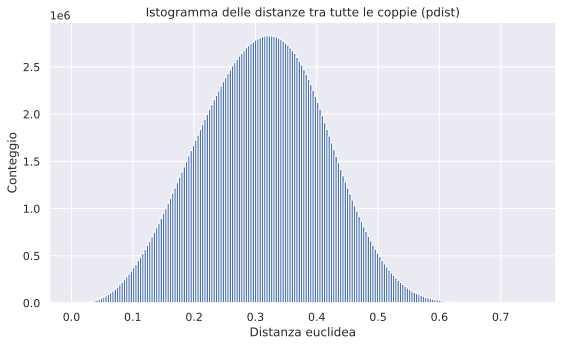

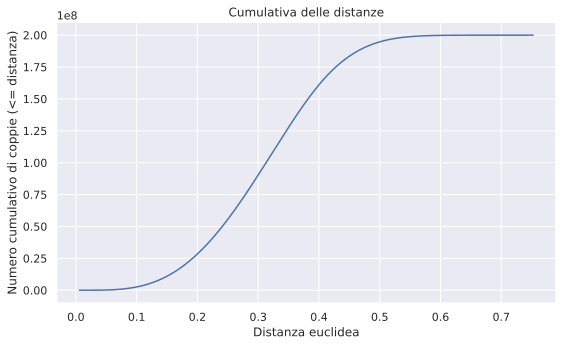

In [2]:
# --- Calcolo delle distanze euclidee tra tutte le coppie di punti del LHS ---
import numpy as np
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# Assumo lhs_scaled è un array JAX (jnp). Convertiamo a numpy se necessario:
try:
    lhs_np = np.asarray(lhs_scaled)  # se lhs_scaled è jnp, va bene
except Exception as e:
    lhs_np = lhs_scaled  # fallback

n_samples = lhs_np.shape[0]
print(f"Numero di campioni nel LHS: {n_samples} (coppie totali = {n_samples*(n_samples-1)//2})")

# Parametri plotting
bins = 200
outdir="fisher_results_large"
# Primo tentativo: usare scipy.spatial.distance.pdist (memoria: ~ n*(n-1)/2 floats)
try:
    dists_condensed = pdist(lhs_np, metric='euclidean')  # vettore condensato (length = n*(n-1)/2)
    # Statistiche
    d_min = dists_condensed.min()
    d_max = dists_condensed.max()
    d_mean = dists_condensed.mean()
    d_std = dists_condensed.std(ddof=0)
    print("Statistiche (pdist):")
    print(f"  min = {d_min:.6e}")
    print(f"  max = {d_max:.6e}")
    print(f"  mean = {d_mean:.6e}")
    print(f"  std = {d_std:.6e}")

    # Plot: istogramma distanza vs conteggi
    plt.figure(figsize=(8,5))
    plt.hist(dists_condensed, bins=bins)
    plt.xlabel("Distanza euclidea")
    plt.ylabel("Conteggio")
    plt.title("Istogramma delle distanze tra tutte le coppie (pdist)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"histo_large.png"), dpi=200)
    plt.show()

    # Plot cumulativo (opzionale): numero di coppie con distanza <= x
    counts, bin_edges = np.histogram(dists_condensed, bins=bins)
    cumsum = np.cumsum(counts)
    plt.figure(figsize=(8,5))
    plt.plot(bin_edges[1:], cumsum)
    plt.xlabel("Distanza euclidea")
    plt.ylabel("Numero cumulativo di coppie (<= distanza)")
    plt.title("Cumulativa delle distanze")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"histo_large_cumu.png"), dpi=200)
    plt.show()

except MemoryError as me:
    print("MemoryError con pdist: provo metodo a blocchi (memory-safe).")
    raise
except Exception as e:
    # Se qualcosa va storto (es. troppa memoria), eseguiamo la versione a blocchi
    print("pdist non ha funzionato (eccezione):", repr(e))
    print("Eseguo versione a blocchi (più lenta ma consuma meno memoria).")

    # --- Versione a blocchi (memory-friendly) ---
    # Definiamo bins condivisi per costruire l'istogramma senza salvare tutte le distanze
    min_possible = 0.0
    # un'upper bound approssimativa per le distanze: diametro dello spazio dei parametri
    # calcoliamo min/max per ogni dimensione e usiamo la radice quadrata della somma dei quadrati delle ampiezze
    ranges = lhs_np.max(axis=0) - lhs_np.min(axis=0)
    approx_max_dist = np.sqrt(np.sum(ranges**2))
    max_edge = approx_max_dist * 1.01
    hist_bins = np.linspace(min_possible, max_edge, bins + 1)
    hist_counts = np.zeros(bins, dtype=np.int64)

    # Per statistica online (Welford per mean+var) su tutte le distanze senza salvarle:
    # ma dobbiamo iterare su tutte le coppie (i<j); lo facciamo a blocchi per le righe
    from math import ceil
    block_size = 500  # aggiusta in base alla RAM; riduci se ancora memoria insufficiente
    total_pairs = 0
    mean = 0.0
    M2 = 0.0

    for i0 in range(0, n_samples, block_size):
        i1 = min(n_samples, i0 + block_size)
        A = lhs_np[i0:i1]  # shape (b, d)
        # compute distances from A to all samples with j>i (to avoid double-count)
        # We will compute distances to B = lhs_np[i1:] and also within A itself (upper triangle)
        # 1) distances A vs rest (j >= i1)
        if i1 < n_samples:
            B = lhs_np[i1:]
            # pairwise distances A x B
            # shape (b, n_samples-i1)
            # efficient using broadcasting:
            # expand dims: A[:, None, :] - B[None, :, :] -> (b, m, d)
            diffs = A[:, None, :] - B[None, :, :]
            dblock = np.sqrt(np.sum(diffs**2, axis=2)).ravel()
            # update histogram
            counts, _ = np.histogram(dblock, bins=hist_bins)
            hist_counts += counts
            # update online stats
            for x in dblock:
                total_pairs += 1
                delta = x - mean
                mean += delta / total_pairs
                delta2 = x - mean
                M2 += delta * delta2

        # 2) distances within A (upper triangle)
        if i1 - i0 > 1:
            # compute condensed pdist for A block
            from scipy.spatial.distance import pdist as _pdist
            d_within = _pdist(A, metric='euclidean')
            counts, _ = np.histogram(d_within, bins=hist_bins)
            hist_counts += counts
            for x in d_within:
                total_pairs += 1
                delta = x - mean
                mean += delta / total_pairs
                delta2 = x - mean
                M2 += delta * delta2

    if total_pairs == 0:
        raise RuntimeError("Nessuna coppia trovata; controlla n_samples.")
    variance = M2 / total_pairs
    std = np.sqrt(variance)

    # ricavo min e max dalle bins che hanno conteggio > 0 (approssimati dai bordi)
    nonzero_bins = np.where(hist_counts > 0)[0]
    if len(nonzero_bins) == 0:
        d_min = 0.0
        d_max = 0.0
    else:
        d_min = hist_bins[nonzero_bins[0]]
        d_max = hist_bins[nonzero_bins[-1] + 1]

    print("Statistiche (metodo a blocchi, approssimato dalla binned-hist):")
    print(f"  min ≈ {d_min:.6e}")
    print(f"  max ≈ {d_max:.6e}")
    print(f"  mean = {mean:.6e}")
    print(f"  std  = {std:.6e}")
    print(f"  coppie considerate = {total_pairs}")

    # Plot histogram (dal conteggio costruito)
    bin_centers = 0.5 * (hist_bins[:-1] + hist_bins[1:])
    plt.figure(figsize=(8,5))
    plt.bar(bin_centers, hist_counts, width=(hist_bins[1]-hist_bins[0]))
    plt.xlabel("Distanza euclidea")
    plt.ylabel("Conteggio")
    plt.title("Istogramma (versione a blocchi)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("histo_large.png")
    plt.show()

    # Plot cumulativa
    plt.figure(figsize=(8,5))
    plt.plot(bin_centers, np.cumsum(hist_counts))
    plt.xlabel("Distanza euclidea")
    plt.ylabel("Numero cumulativo di coppie (<= distanza)")
    plt.title("Cumulativa delle distanze (blocchi)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
# === Visualizzazione PCA 2D dello spazio dei parametri ===
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Converto a numpy nel caso sia jax array
lhs_np = np.asarray(lhs_scaled)

# PCA a 2 componenti
pca = PCA(n_components=2)
lhs_pca = pca.fit_transform(lhs_np)

print("Varianza spiegata dalle prime 2 componenti PCA:",
      pca.explained_variance_ratio_,
      " -> totale: ", np.sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8, 6))
plt.scatter(lhs_pca[:, 0], lhs_pca[:, 1], s=10, alpha=0.5)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Distribuzione PCA dei parametri del LHS")
plt.grid(True)
plt.tight_layout()
plt.show()
